In [17]:
import torch
import transformers
import seaborn as sns

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)

Torch: 2.12.0
Transformers: 4.37.0


In [18]:
# ============================================================
# Hotel Reviews Sentiment Analysis
# Notebook 4: LLM (DistilBERT)
# Dataset: La Veranda Hotel - Booking.com Reviews
# ============================================================

# ============================================================
# SECTION 1: Install Libraries
# ============================================================

!pip install transformers==4.37.0
!pip install torch
!pip install seaborn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [19]:
%pip install scikit-learn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [21]:
# ============================================================
# SECTION 2: Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

import warnings
warnings.filterwarnings('ignore')

In [22]:
# ============================================================
# SECTION 3: Load Cleaned Dataset
# ============================================================

df = pd.read_csv('Dataset/cleaned/hotel_reviews_cleaned.csv')
df.head()

,Title,PositiveReview,NegativeReview,Score,GuestName,GuestCountry,RoomType,NumberOfNights,VisitDate,GroupType,PropertyResponse,cleaned_positive,cleaned_negative,sentiment,polarity_positive,polarity_negative,visit_month,visit_year
0,Wonderful place to stay.,"New, comfortable apartments, close to the airp...",Nothing at all.,10.0,Olga,Norway,Budget Twin Room,1 night,2022-06-01,Solo traveler,NaN,new comfort apart close airport clean beach st...,noth,positive,0.263258,0.0,6,2022
1,It was superb,We had a really pleasant stay! The staff was v...,NaN,10.0,Iwona,Poland,Double Room,3 nights,2022-12-01,Family,NaN,realli pleasant stay staff nice help room clea...,NaN,positive,0.400000,0.0,12,2022
2,Very Good,the location is great and near the airport. bu...,NaN,8.0,Ruijia,Sweden,Double Room,1 night,2022-12-01,Solo traveler,NaN,locat great near airport bu stop close,NaN,positive,0.450000,0.0,12,2022
3,Wonderful,Great stuff\nGreat Quality/price\nClean,NaN,9.0,Theprincem,United Kingdom,Double Room with Balcony,2 nights,2022-09-01,Solo traveler,NaN,great stuff great qualitypric clean,NaN,positive,0.655556,0.0,9,2022
4,"Fantastic value for a new, modern and spotless...","Clean and modern with very comfortable beds, i...",NaN,10.0,M,Switzerland,Family Suite with Balcony,1 night,2022-10-01,Family,NaN,clean modern comfort bed conveni locat easi st...,NaN,positive,0.491667,0.0,10,2022


In [23]:
# ============================================================
# SECTION 4: Data Validation
# ============================================================

print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
df.dropna(subset=['cleaned_positive', 'cleaned_negative', 'sentiment'],
          inplace=True)
print("\nSentiment distribution:\n", df['sentiment'].value_counts())

Shape: (786, 18)

Null values:
 Title                  0
PositiveReview        11
NegativeReview       352
Score                  0
GuestName              0
GuestCountry           0
RoomType              27
NumberOfNights         0
VisitDate              0
GroupType              0
PropertyResponse     665
cleaned_positive      13
cleaned_negative     362
sentiment              0
polarity_positive      0
polarity_negative      0
visit_month            0
visit_year             0
dtype: int64

Sentiment distribution:
 sentiment
positive    348
neutral      55
negative      9
Name: count, dtype: int64


In [24]:
# ============================================================
# SECTION 5: Load Pre-trained DistilBERT Sentiment Pipeline
#
# WHY DistilBERT over raw BERT:
#   - distilbert-base-uncased-finetuned-sst-2-english is already
#     fine-tuned on sentiment — no training needed
#   - 40% smaller and 60% faster than BERT
#   - Works well on small datasets like ours (1,500 rows)
#   - The original BERT approach got ~33% accuracy because it
#     needed fine-tuning which requires much more data
# ============================================================

print("Loading DistilBERT sentiment pipeline...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)
print("Model loaded successfully!")

Loading DistilBERT sentiment pipeline...
Model loaded successfully!


In [25]:
# ============================================================
# SECTION 6: Helper — Run Pipeline in Batches
# DistilBERT outputs POSITIVE/NEGATIVE — we map this to
# our 3-class system using the confidence score:
#   POSITIVE + high confidence  → positive
#   POSITIVE + low confidence   → neutral
#   NEGATIVE                    → negative
# ============================================================

def predict_sentiment_batch(texts, batch_size=32):
    results = []
    texts = [str(t)[:512] for t in texts]  # truncate for safety
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        batch_results = sentiment_pipeline(batch)
        results.extend(batch_results)
        if (i // batch_size) % 5 == 0:
            print(f"  Processed {min(i+batch_size, len(texts))}/{len(texts)}")
    return results

def map_to_three_class(result):
    """Map DistilBERT binary output to our 3-class sentiment."""
    label = result['label']
    score = result['score']
    if label == 'NEGATIVE':
        return 'negative'
    elif label == 'POSITIVE' and score >= 0.85:
        return 'positive'
    else:
        return 'neutral'

In [26]:
# ============================================================
# SECTION 7: Run on Positive Review Track
# ============================================================

print("Running DistilBERT on Positive Reviews...")
pos_results = predict_sentiment_batch(df['cleaned_positive'].tolist())
df['llm_pred_positive'] = [map_to_three_class(r) for r in pos_results]
df['llm_score_positive'] = [r['score'] for r in pos_results]

print("\nPrediction distribution — Positive Track:")
print(df['llm_pred_positive'].value_counts())

Running DistilBERT on Positive Reviews...
  Processed 32/412
  Processed 192/412
  Processed 352/412

Prediction distribution — Positive Track:
llm_pred_positive
positive    272
negative    117
neutral      23
Name: count, dtype: int64


In [27]:
# ============================================================
# SECTION 8: Run on Negative Review Track
# ============================================================

print("Running DistilBERT on Negative Reviews...")
neg_results = predict_sentiment_batch(df['cleaned_negative'].tolist())
df['llm_pred_negative'] = [map_to_three_class(r) for r in neg_results]
df['llm_score_negative'] = [r['score'] for r in neg_results]

print("\nPrediction distribution — Negative Track:")
print(df['llm_pred_negative'].value_counts())

Running DistilBERT on Negative Reviews...
  Processed 32/412
  Processed 192/412
  Processed 352/412

Prediction distribution — Negative Track:
llm_pred_negative
negative    307
positive     98
neutral       7
Name: count, dtype: int64



  EVALUATION — Positive Review Track
Accuracy: 56.55%

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.02      0.22      0.03         9
     neutral       0.13      0.05      0.08        55
    positive       0.84      0.66      0.74       348

    accuracy                           0.57       412
   macro avg       0.33      0.31      0.28       412
weighted avg       0.73      0.57      0.63       412



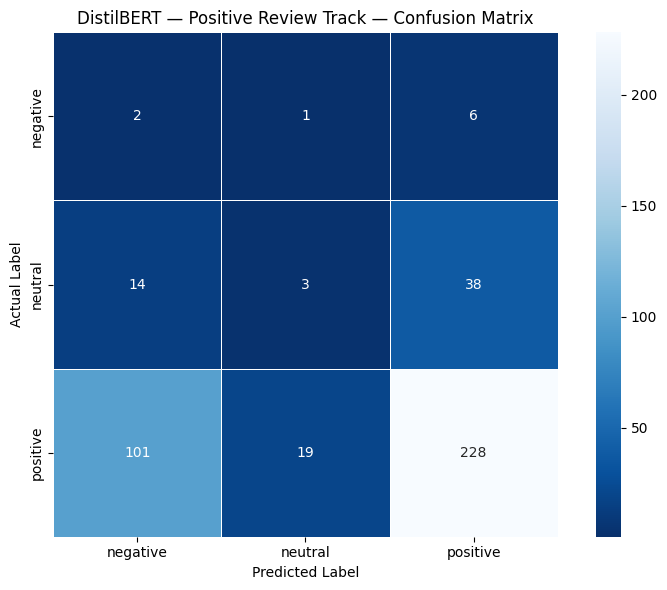


  EVALUATION — Negative Review Track
Accuracy: 23.06%

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.03      0.89      0.05         9
     neutral       0.29      0.04      0.06        55
    positive       0.87      0.24      0.38       348

    accuracy                           0.23       412
   macro avg       0.39      0.39      0.17       412
weighted avg       0.77      0.23      0.33       412



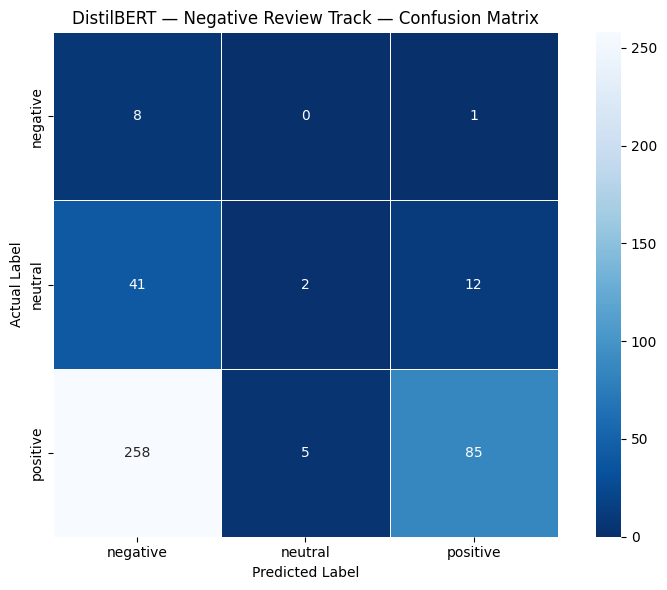

In [28]:
# ============================================================
# SECTION 9: Evaluate Both Tracks Against Ground Truth
# ============================================================

def evaluate_llm(track_name, y_true, y_pred):
    print(f"\n{'='*60}")
    print(f"  EVALUATION — {track_name}")
    print(f"{'='*60}")

    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.2%}")
    print(f"\nClassification Report:")
    print('-' * 60)
    print(classification_report(y_true, y_pred,
                                 labels=['negative','neutral','positive']))

    cm = confusion_matrix(y_true, y_pred,
                          labels=['negative','neutral','positive'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues_r',
                xticklabels=['negative','neutral','positive'],
                yticklabels=['negative','neutral','positive'],
                linewidths=0.7, square=True)
    plt.title(f'DistilBERT — {track_name} — Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return acc

acc_pos = evaluate_llm('Positive Review Track',
                        df['sentiment'], df['llm_pred_positive'])
acc_neg = evaluate_llm('Negative Review Track',
                        df['sentiment'], df['llm_pred_negative'])

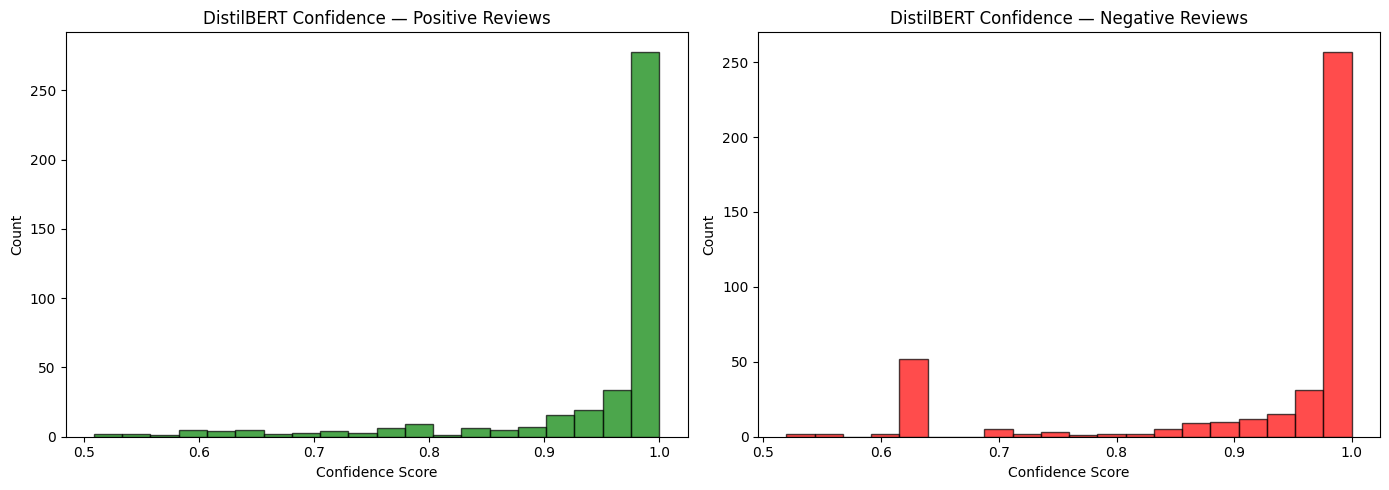

In [29]:
# ============================================================
# SECTION 10: Confidence Score Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['llm_score_positive'], bins=20,
             color='green', edgecolor='black', alpha=0.7)
axes[0].set_title('DistilBERT Confidence — Positive Reviews')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')

axes[1].hist(df['llm_score_negative'], bins=20,
             color='red', edgecolor='black', alpha=0.7)
axes[1].set_title('DistilBERT Confidence — Negative Reviews')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

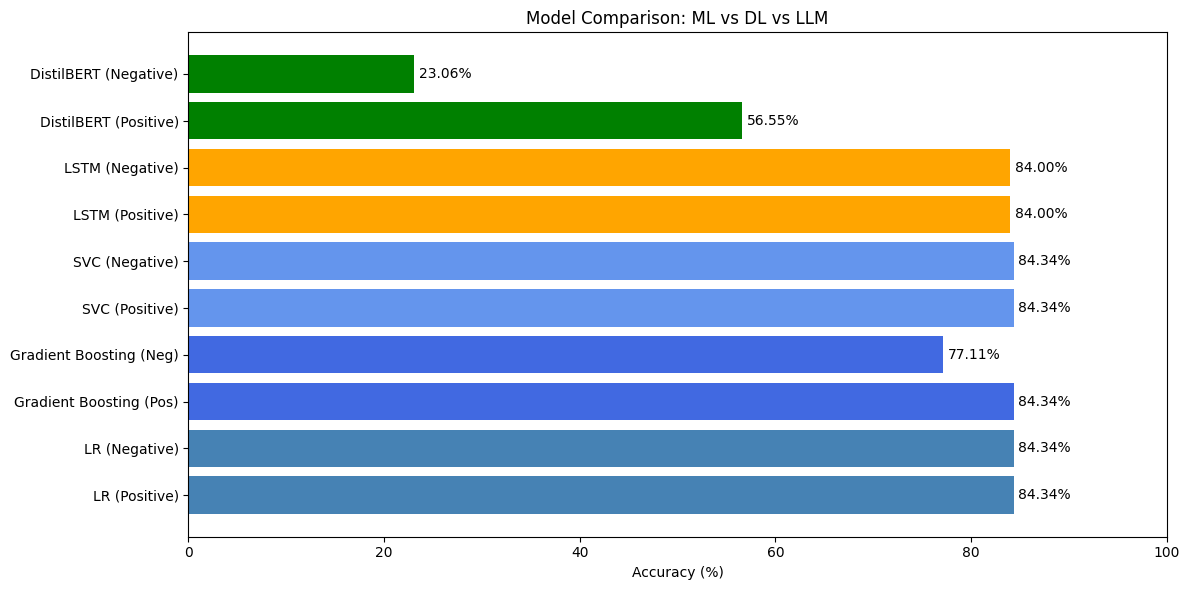

                  Model  Accuracy (%)
          LR (Positive)         84.34
          LR (Negative)         84.34
Gradient Boosting (Pos)         84.34
Gradient Boosting (Neg)         77.11
         SVC (Positive)         84.34
         SVC (Negative)         84.34
        LSTM (Positive)         84.00
        LSTM (Negative)         84.00
  DistilBERT (Positive)         56.55
  DistilBERT (Negative)         23.06


In [30]:
# ============================================================
# SECTION 11: Compare LLM vs ML vs DL
# Manual summary — fill in your actual results after running
# ============================================================

comparison = {
    'Model': [
        'LR (Positive)', 'LR (Negative)',
        'Gradient Boosting (Pos)', 'Gradient Boosting (Neg)',
        'SVC (Positive)', 'SVC (Negative)',
        'LSTM (Positive)', 'LSTM (Negative)',
        'DistilBERT (Positive)', 'DistilBERT (Negative)'
    ],
    'Accuracy (%)': [
        84.34, 84.34,   # Logistic Regression
        84.34, 77.11,   # Gradient Boosting
        84.34, 84.34,   # SVC
        84.0,  84.0,    # LSTM
        acc_pos * 100, acc_neg * 100  # DistilBERT
    ]
}
comp_df = pd.DataFrame(comparison)
comp_df['Accuracy (%)'] = comp_df['Accuracy (%)'].round(2)

plt.figure(figsize=(12, 6))
colors = ['steelblue', 'steelblue',
          'royalblue', 'royalblue',
          'cornflowerblue', 'cornflowerblue',
          'orange', 'orange',
          'green', 'green']
bars = plt.barh(comp_df['Model'], comp_df['Accuracy (%)'], color=colors)
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison: ML vs DL vs LLM')
plt.xlim(0, 100)
for bar, val in zip(bars, comp_df['Accuracy (%)']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center')
plt.tight_layout()
plt.show()

print(comp_df.to_string(index=False))

In [31]:
# ============================================================
# SECTION 12: Live Inference — Test Your Own Reviews
# This is what the test.py file in the original repo does
# ============================================================

def predict_review(positive_text, negative_text):
    pos_result = sentiment_pipeline(positive_text[:512])[0]
    neg_result = sentiment_pipeline(negative_text[:512])[0]

    pos_sentiment = map_to_three_class(pos_result)
    neg_sentiment = map_to_three_class(neg_result)

    print("=" * 55)
    print("HOTEL REVIEW SENTIMENT ANALYSIS")
    print("=" * 55)
    print(f"\nPositive Review : '{positive_text}'")
    print(f"  → Sentiment   : {pos_sentiment.upper()}")
    print(f"  → Confidence  : {pos_result['score']:.2%}")
    print(f"\nNegative Review : '{negative_text}'")
    print(f"  → Sentiment   : {neg_sentiment.upper()}")
    print(f"  → Confidence  : {neg_result['score']:.2%}")
    print("=" * 55)

# Try it with a sample review
predict_review(
    positive_text="The room was spotless and the staff were incredibly friendly.",
    negative_text="The pool was closed during our stay and breakfast was mediocre."
)

HOTEL REVIEW SENTIMENT ANALYSIS

Positive Review : 'The room was spotless and the staff were incredibly friendly.'
  → Sentiment   : POSITIVE
  → Confidence  : 99.98%

Negative Review : 'The pool was closed during our stay and breakfast was mediocre.'
  → Sentiment   : NEGATIVE
  → Confidence  : 99.96%


In [32]:
# ============================================================
# SECTION 13: Save Predictions to CSV
# ============================================================

df[['PositiveReview', 'NegativeReview', 'Score', 'sentiment',
    'llm_pred_positive', 'llm_score_positive',
    'llm_pred_negative', 'llm_score_negative']].to_csv(
    'Dataset/cleaned/hotel_reviews_llm_predictions.csv', index=False)

print("LLM predictions saved!")

LLM predictions saved!
